In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gpplot as gpp
from scipy.stats import normaltest
from sklearn.metrics import roc_curve, auc
from statannotations.Annotator import Annotator
from statsmodels.stats.multitest import multipletests
import scipy.stats as stats 
import random
import scipy

gpp.set_aesthetics(context = 'paper')

In [4]:
reads_df=pd.read_table("../Data/counts-EK20250627_Jacquere_allinone.txt")
reads_df=reads_df.drop(["Empty","Construct IDs"],axis=1)
reads_df

,Construct Barcode,A375_CP0082_repA,A375_CP0082_repB,A549_CP0082_repA,A549_CP0082_repB,CP0082_pDNA
0,AAAAAAGAAAGGATACGTCC,537,545,637,587,202
1,AAAAACAGCTGATGAAACCT,693,1170,1367,1544,235
2,AAAAACCTGGGAAAGATATA,1742,2360,1911,2648,339
3,AAAAAGAGGCGGCATTACAG,1530,1881,2557,2291,415
4,AAAAAGATAGATGTGCTAAA,60,36,96,79,303
...,...,...,...,...,...,...
60545,TTTGTGGAGCCGGTACATGA,3091,3213,2809,3054,461
60546,TTTGTGGGTACATCTAACCC,1273,1289,977,1554,224
60547,TTTGTGGTAGGAGTAGGTGT,762,412,757,584,269
60548,TTTGTGTATTACCTCAGGAA,370,678,453,658,200


In [5]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads
condition_columns = ['A375_CP0082_repA',
       'A375_CP0082_repB', 'A549_CP0082_repA', 'A549_CP0082_repB',
       'CP0082_pDNA']
lognorm_df = reads_df.copy()
lognorm_df[condition_columns] = lognorm_df[condition_columns].apply(lognorm)
condition_columns.remove('CP0082_pDNA')
lognorm_df

,Construct Barcode,A375_CP0082_repA,A375_CP0082_repB,A549_CP0082_repA,A549_CP0082_repB,CP0082_pDNA
0,AAAAAAGAAAGGATACGTCC,2.713788,2.691524,3.006379,2.744796,3.473443
1,AAAAACAGCTGATGAAACCT,3.031349,3.669182,4.008814,4.000054,3.673393
2,AAAAACCTGGGAAAGATATA,4.250788,4.623112,4.466389,4.740195,4.166903
3,AAAAAGAGGCGGCATTACAG,4.074037,4.310656,4.869930,4.539656,4.443945
4,AAAAAGATAGATGTGCTAAA,0.697130,0.444304,1.042846,0.821725,4.014447
...,...,...,...,...,...,...
60545,TTTGTGGAGCCGGTACATGA,5.044659,5.052619,5.001102,4.938798,4.588971
60546,TTTGTGGGTACATCTAACCC,3.825928,3.798418,3.559569,4.008788,3.609773
60547,TTTGTGGTAGGAGTAGGTGT,3.152216,2.358262,3.226633,2.738509,3.853975
60548,TTTGTGTATTACCTCAGGAA,2.272382,2.962064,2.585739,2.886110,3.460386


In [6]:
#remove underrepresented sgRNAs
filtered_lognorms = lognorm_df.copy()
z_low = -3  # minimum z-score
# Z-score the pDNA column
filtered_lognorms["pDNA_zscore"] = (filtered_lognorms['CP0082_pDNA'] - filtered_lognorms['CP0082_pDNA'].mean())/filtered_lognorms['CP0082_pDNA'].std()
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms["pDNA_zscore"] > z_low].reset_index(drop=True)
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop("pDNA_zscore", axis=1)
filtered_lognorms

,Construct Barcode,A375_CP0082_repA,A375_CP0082_repB,A549_CP0082_repA,A549_CP0082_repB,CP0082_pDNA
0,AAAAAAGAAAGGATACGTCC,2.713788,2.691524,3.006379,2.744796,3.473443
1,AAAAACAGCTGATGAAACCT,3.031349,3.669182,4.008814,4.000054,3.673393
2,AAAAACCTGGGAAAGATATA,4.250788,4.623112,4.466389,4.740195,4.166903
3,AAAAAGAGGCGGCATTACAG,4.074037,4.310656,4.869930,4.539656,4.443945
4,AAAAAGATAGATGTGCTAAA,0.697130,0.444304,1.042846,0.821725,4.014447
...,...,...,...,...,...,...
60253,TTTGTGGAGCCGGTACATGA,5.044659,5.052619,5.001102,4.938798,4.588971
60254,TTTGTGGGTACATCTAACCC,3.825928,3.798418,3.559569,4.008788,3.609773
60255,TTTGTGGTAGGAGTAGGTGT,3.152216,2.358262,3.226633,2.738509,3.853975
60256,TTTGTGTATTACCTCAGGAA,2.272382,2.962064,2.585739,2.886110,3.460386


In [7]:
#get log fold change from pDNA
lfc_df = filtered_lognorms.copy()
for col in condition_columns:
    lfc_df[col] = filtered_lognorms[col] - filtered_lognorms["CP0082_pDNA"]
lfc_df=lfc_df.drop("CP0082_pDNA",axis=1)
lfc_df

,Construct Barcode,A375_CP0082_repA,A375_CP0082_repB,A549_CP0082_repA,A549_CP0082_repB
0,AAAAAAGAAAGGATACGTCC,-0.759655,-0.781919,-0.467064,-0.728647
1,AAAAACAGCTGATGAAACCT,-0.642044,-0.004211,0.335421,0.326662
2,AAAAACCTGGGAAAGATATA,0.083885,0.456208,0.299485,0.573292
3,AAAAAGAGGCGGCATTACAG,-0.369908,-0.133289,0.425985,0.095711
4,AAAAAGATAGATGTGCTAAA,-3.317317,-3.570143,-2.971601,-3.192722
...,...,...,...,...,...
60253,TTTGTGGAGCCGGTACATGA,0.455688,0.463648,0.412131,0.349827
60254,TTTGTGGGTACATCTAACCC,0.216155,0.188645,-0.050204,0.399015
60255,TTTGTGGTAGGAGTAGGTGT,-0.701758,-1.495712,-0.627342,-1.115466
60256,TTTGTGTATTACCTCAGGAA,-1.188004,-0.498322,-0.874647,-0.574276


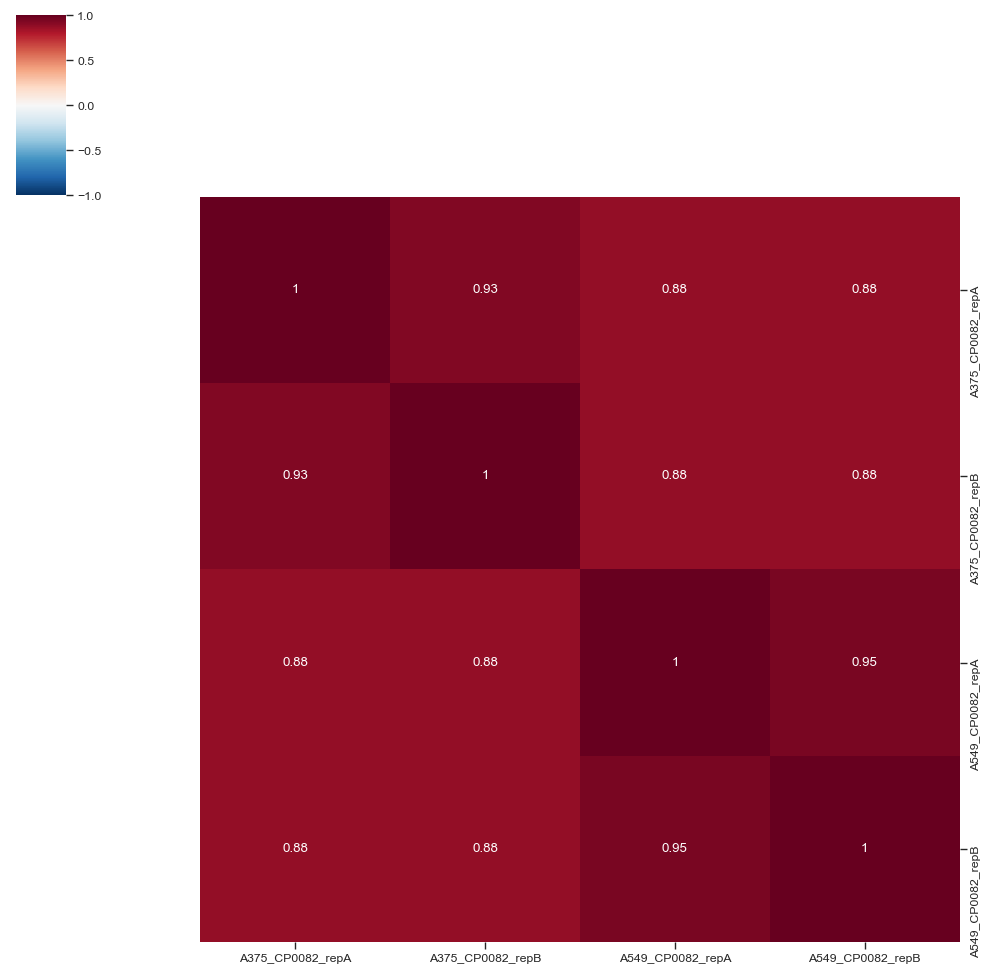

In [8]:
#check replicate correlation
lfc_correlations = lfc_df.corr(numeric_only=True)
sns.clustermap(lfc_correlations, cmap='RdBu_r',
               vmin=-1, vmax=1, annot=True,row_cluster=False,col_cluster=False)
gpp.savefig("../Figures/jacquere_allinone_replicate_correlation.pdf")

In [9]:
#Replicate correlation is satisfactory: average replicates

condition_map = {'A375_CP0082_repA': 'Jacquere A375',
                 'A375_CP0082_repB': 'Jacquere A375',
                 'A549_CP0082_repA': 'Jacquere A549',
                 'A549_CP0082_repB': 'Jacquere A549'}

long_lfcs = (lfc_df.melt(id_vars='Construct Barcode',
                         var_name='condition', value_name='lfc'))

long_lfcs['condition'] = long_lfcs['condition'].map(condition_map)
lfcs_replicates_averaged = (long_lfcs.groupby(['Construct Barcode', 'condition'])
            .agg(sgRNA_lfc = ('lfc', 'mean'))
            .reset_index())
lfcs_replicates_averaged

,Construct Barcode,condition,sgRNA_lfc
0,AAAAAAGAAAGGATACGTCC,Jacquere A375,-0.770787
1,AAAAAAGAAAGGATACGTCC,Jacquere A549,-0.597856
2,AAAAACAGCTGATGAAACCT,Jacquere A375,-0.323128
3,AAAAACAGCTGATGAAACCT,Jacquere A549,0.331041
4,AAAAACCTGGGAAAGATATA,Jacquere A375,0.270047
...,...,...,...
120511,TTTGTGGTAGGAGTAGGTGT,Jacquere A549,-0.871404
120512,TTTGTGTATTACCTCAGGAA,Jacquere A375,-0.843163
120513,TTTGTGTATTACCTCAGGAA,Jacquere A549,-0.724461
120514,TTTGTTGGATACGAAGTGAA,Jacquere A375,0.558674


In [10]:
#read in guide level annotations (supplementary file from manuscript)
guide_mappings_compressed = pd.read_csv("../Data/Jacquere_PerGuideAnnotations.csv")

#get target-level information as a unique row (guides that have numerous targets are thus repeated)
guide_mapping=guide_mappings_compressed.apply(lambda x: x.str.split("|")).explode(column=[col for col in guide_mappings_compressed.columns if col not in ["sgRNA Sequence","Other Target Matches"]])
guide_mapping["sgRNA Sequence"]=guide_mapping["sgRNA Sequence"].apply(lambda x: "".join(x))
guide_mapping=guide_mapping.drop("Other Target Matches",axis=1)

#identify additional genes to which each guide maps; gene effects should be determined from ALL mapping guides, regardless of intended target
guides_with_additional_genesmapped= guide_mappings_compressed[guide_mappings_compressed["Other Target Matches"]!="[]"][["sgRNA Sequence","Other Target Matches"]]
guides_with_additional_genesmapped["Other Target Matches"]=guides_with_additional_genesmapped["Other Target Matches"].apply(lambda x: x.strip("[]").replace("'", "").split(", ") if x != '[]' else list())
guides_with_additional_genesmapped=guides_with_additional_genesmapped.explode("Other Target Matches")
guides_with_additional_genesmapped=guides_with_additional_genesmapped.rename(columns={"Other Target Matches":"Target Gene Symbol"})
guides_with_additional_genesmapped=guides_with_additional_genesmapped.drop_duplicates()
guide_mapping=pd.concat([guide_mapping,guides_with_additional_genesmapped])
#for guides with NA gene symbol, use Gene ID instead
guide_mapping["Target Gene Symbol"]=guide_mapping.apply(lambda x: x["Target Gene ID"] if x["Target Gene Symbol"]=="nan" else x["Target Gene Symbol"],axis=1)
guide_mapping

,sgRNA Sequence,Target Gene ID,Source,Target Gene Symbol,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score
0,GTAGTGACCTCCATCCCCCA,ENSG00000121410,GENCODE,A1BG,ENST00000263100.8,NC_000019.10,+,58351487,5,1.9481,0,0,1.138
1,ACTGGCGCCATCGAGAGCCA,ENSG00000121410,GENCODE,A1BG,ENST00000263100.8,NC_000019.10,+,58352536,4,1.5,0,0,0.928
2,GTGGAGTGGACTTCCAGCTA,ENSG00000121410,GENCODE,A1BG,ENST00000263100.8,NC_000019.10,-,58351575,5,0.0,0,0,1.212
3,ATGACTCTCATACTCCACGA,ENSG00000148584,GENCODE,A1CF,ENST00000373997.8,NC_000010.11,+,50836128,6,0.7222,0,0,1.453
4,GAAGACAGGAGCTCCAAGGT,ENSG00000148584,GENCODE,A1CF,ENST00000373997.8,NC_000010.11,+,50816123,9,0.0,0,0,1.039
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59545,CATTGGTATCCAAAACACTG,NaN,NaN,KMT2E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59546,AAGATCATGAAAAATACGGT,NaN,NaN,MRPL30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59547,CATGAATAACAGCTGGCATC,NaN,NaN,LIMS3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59547,CATGAATAACAGCTGGCATC,NaN,NaN,LIMS4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#join data with guide annotations
annotated_sgrna_lfcs = lfcs_replicates_averaged.merge(guide_mapping,how='inner',left_on='Construct Barcode',right_on="sgRNA Sequence")
annotated_sgrna_lfcs=annotated_sgrna_lfcs.drop("sgRNA Sequence",axis=1)
annotated_sgrna_lfcs

,Construct Barcode,condition,sgRNA_lfc,Target Gene ID,Source,Target Gene Symbol,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score
0,AAAAAAGAAAGGATACGTCC,Jacquere A375,-0.770787,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139
1,AAAAAAGAAAGGATACGTCC,Jacquere A549,-0.597856,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139
2,AAAAACAGCTGATGAAACCT,Jacquere A375,-0.323128,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047
3,AAAAACAGCTGATGAAACCT,Jacquere A549,0.331041,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047
4,AAAAACCTGGGAAAGATATA,Jacquere A375,0.270047,ENSG00000188295,GENCODE,ZNF669,ENST00000448299.7,NC_000001.11,-,247101736,3,1.5184,0,0,0.958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131587,TTTGTGGTAGGAGTAGGTGT,Jacquere A549,-0.871404,ENSG00000161999,GENCODE,JMJD8,ENST00000609261.6,NC_000016.10,+,683703,4,1.6667,0,0,0.9859
131588,TTTGTGTATTACCTCAGGAA,Jacquere A375,-0.843163,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334
131589,TTTGTGTATTACCTCAGGAA,Jacquere A549,-0.724461,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334
131590,TTTGTTGGATACGAAGTGAA,Jacquere A375,0.558674,ENSG00000120860,GENCODE,WASHC3,ENST00000240079.11,NC_000012.12,+,102046103,3,0.8667,0,0,0.3445


In [12]:
#export for analysis of hit calling methods 
annotated_sgrna_lfcs[annotated_sgrna_lfcs["condition"]=="Jacquere A375"].to_csv("../Data/jacquereA375lfc.csv")

Statistics=211.012, p=0.000 length= 1794


Text(0.5, 0, 'Log2 fold change')

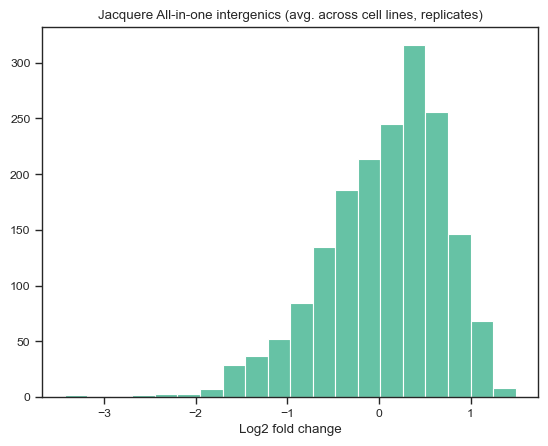

In [13]:
control_sgrna_lfcs = annotated_sgrna_lfcs[(annotated_sgrna_lfcs['Target Gene Symbol'].str.count("INTERGENIC")>0)].reset_index(drop=True)

#testing if controls are normally distributed with D'Agostino-Pearson K2 test
stat, p = normaltest(control_sgrna_lfcs["sgRNA_lfc"])
print('Statistics=%.3f, p=%.3f' % (stat, p),"length=",len(control_sgrna_lfcs))

control_sgrna_lfcs["sgRNA_lfc"].hist(grid=False,bins=20)
plt.title("Jacquere All-in-one intergenics (avg. across cell lines, replicates)")
plt.xlabel("Log2 fold change")

The result of the D'Agostino-Pearson K2 demonstrates that the controls are not normally distributed; z-scores should not be interpreted directly for statistical significance

In [14]:
control_sgrna_stats = (control_sgrna_lfcs.groupby('condition')
                       .agg(neg_ctl_mean = ('sgRNA_lfc', 'mean'),
                            neg_ctl_sd = ('sgRNA_lfc', 'std'))
                       .reset_index())

zscored_sgrna_lfcs = annotated_sgrna_lfcs.copy()
zscored_sgrna_lfcs = (zscored_sgrna_lfcs.merge(control_sgrna_stats,
                                               how='inner', on='condition'))
zscored_sgrna_lfcs['z_scored_sgRNA_lfc'] = ((zscored_sgrna_lfcs['sgRNA_lfc'] - zscored_sgrna_lfcs['neg_ctl_mean'])/
                                          zscored_sgrna_lfcs['neg_ctl_sd'])
zscored_sgrna_lfcs = zscored_sgrna_lfcs.drop(['neg_ctl_sd', 'neg_ctl_mean','sgRNA_lfc'], axis=1)
zscored_sgrna_lfcs

,Construct Barcode,condition,Target Gene ID,Source,Target Gene Symbol,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score,z_scored_sgRNA_lfc
0,AAAAAAGAAAGGATACGTCC,Jacquere A375,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139,-1.226337
1,AAAAAAGAAAGGATACGTCC,Jacquere A549,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139,-1.012389
2,AAAAACAGCTGATGAAACCT,Jacquere A375,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047,-0.564372
3,AAAAACAGCTGATGAAACCT,Jacquere A549,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047,0.432301
4,AAAAACCTGGGAAAGATATA,Jacquere A375,ENSG00000188295,GENCODE,ZNF669,ENST00000448299.7,NC_000001.11,-,247101736,3,1.5184,0,0,0.958,0.312770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131587,TTTGTGGTAGGAGTAGGTGT,Jacquere A549,ENSG00000161999,GENCODE,JMJD8,ENST00000609261.6,NC_000016.10,+,683703,4,1.6667,0,0,0.9859,-1.437831
131588,TTTGTGTATTACCTCAGGAA,Jacquere A375,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334,-1.333360
131589,TTTGTGTATTACCTCAGGAA,Jacquere A549,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334,-1.209296
131590,TTTGTTGGATACGAAGTGAA,Jacquere A375,ENSG00000120860,GENCODE,WASHC3,ENST00000240079.11,NC_000012.12,+,102046103,3,0.8667,0,0,0.3445,0.739569


In [15]:
zscored_sgrna_lfcs.to_csv("../Data/jacquere_allinone_CP0082_zscores.csv",index=False)

### Identifying Jacquere vs. Brunello Library Performance

Identifying performance of library at separating essentials, nonessentials and comparing to screen of Brunello Library (Sanson et al, *Nature Communications*, 2018)

In [16]:
brunello_zscores=pd.read_csv("../Data/brunello_zscores.csv")
brunello_zscores = brunello_zscores.rename(columns={'sgRNA Sequence': 'Construct Barcode'})
brunello_zscores["condition"]="Brunello A375"
jacquere_and_brunello=pd.concat([zscored_sgrna_lfcs,brunello_zscores])

In [17]:
#export for analysis of hit calling methods
jacquere_and_brunello[jacquere_and_brunello["condition"].isin(["Jacquere A375","Brunello A375"])].to_csv("../Data/jacquere_brunello_guideinfo.csv",index=False)


In [18]:
noness_genes = pd.read_csv("../Data/AchillesNonessentialControls.csv")
noness_genes["Gene"]=noness_genes["Gene"].apply(lambda x: x.split("(")[0])
#remove space from gene name 
noness_genes["Gene"]=noness_genes["Gene"].str.replace(" ","")

essential_genes = pd.read_csv("../Data/AchillesCommonEssentialControls.csv")
essential_genes["Gene"]=essential_genes["Gene"].apply(lambda x: x.split("(")[0])
#remove space from gene name 
essential_genes["Gene"]=essential_genes["Gene"].str.replace(" ","")

In [19]:
# ROC-AUC of essential vs nonessential genes 

jacquere_and_brunello_eval =  jacquere_and_brunello.copy()
jacquere_and_brunello_eval['Essential'] = jacquere_and_brunello_eval['Target Gene Symbol'].isin(essential_genes["Gene"].tolist())
jacquere_and_brunello_eval['Nonessential'] = jacquere_and_brunello_eval['Target Gene Symbol'].isin(noness_genes["Gene"].tolist())
jacquere_and_brunello_eval = (jacquere_and_brunello_eval[jacquere_and_brunello_eval['Essential'] | jacquere_and_brunello_eval['Nonessential']].reset_index(drop=True))
tpr_fpr_df_list = []
roc_auc_list = []
for group, df in jacquere_and_brunello_eval.groupby('condition'):
    fpr, tpr, threshold = roc_curve(df['Essential'], -df['z_scored_sgRNA_lfc'])
    group_tpr_fpr_df = pd.DataFrame({'True Positive Rate': tpr, 'False Positive Rate': fpr, 'threshold': threshold})
    group_tpr_fpr_df['condition'] = group
    tpr_fpr_df_list.append(group_tpr_fpr_df)
    roc_auc = auc(fpr, tpr)
    roc_auc_list.append({'condition': group, 'ROC-AUC': roc_auc})
sgrna_roc_aucs = pd.DataFrame(roc_auc_list)
sgrna_tpr_fpr_df = (pd.concat(tpr_fpr_df_list).reset_index(drop=True))


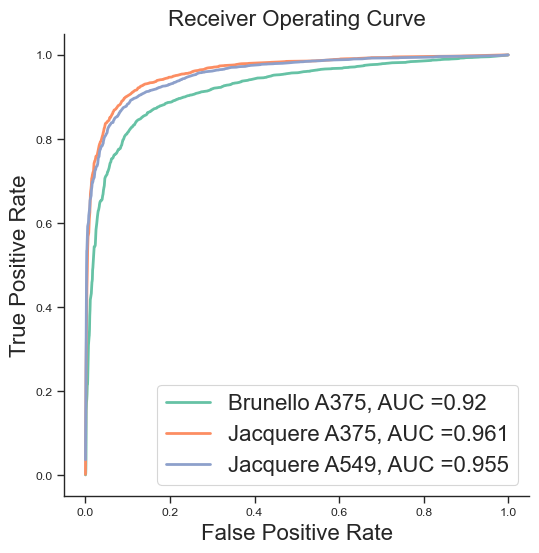

In [20]:
ROC_AUC_map = sgrna_roc_aucs.set_index('condition').to_dict()
sgrna_tpr_fpr_df['ROC-AUC'] = sgrna_tpr_fpr_df['condition'].map(ROC_AUC_map["ROC-AUC"])
sgrna_tpr_fpr_df["Screen"]=sgrna_tpr_fpr_df['condition']+", AUC ="+round(sgrna_tpr_fpr_df['ROC-AUC'],3).astype(str)

plt.subplots(figsize=(6, 6))
sns.lineplot(data=sgrna_tpr_fpr_df, x='False Positive Rate', linewidth=2,
             y='True Positive Rate', hue='Screen', errorbar=None)
plt.legend(fontsize=16)
plt.xlabel(xlabel="False Positive Rate",fontsize=16)
plt.ylabel(ylabel="True Positive Rate",fontsize=16)
plt.title("Receiver Operating Curve",fontsize=16)
sns.despine()
gpp.savefig("../Figures/Jacquere_vs_Brunello_ROC.pdf")

Calculating precision recall curve 

In [21]:
def calc_precision(data,predicted_cutoff):
    true_positives= len(data.loc[(data["z_scored_sgRNA_lfc"]<predicted_cutoff) & (data["Essential"])])
    false_positives= len(data.loc[(data["z_scored_sgRNA_lfc"]<predicted_cutoff) & (data["Nonessential"])])
    total_positive_predictions= true_positives + false_positives
    return (true_positives/total_positive_predictions)
def calc_recall(data,predicted_cutoff):
    true_positives= len(data.loc[(data["z_scored_sgRNA_lfc"]<predicted_cutoff) & (data["Essential"])])
    false_negatives= len(data.loc[(data["z_scored_sgRNA_lfc"]>predicted_cutoff) & (data["Essential"])])
    total_actual_positives= true_positives + false_negatives
    return (true_positives/total_actual_positives)
    
def calc_precision_recall(df):
    cutoff_precision_full=[]
    cutoff_recall_full=[]
    cutoffs_totest=[x*0.01 for x in range(round(df["z_scored_sgRNA_lfc"].min() *100)+1,round(df["z_scored_sgRNA_lfc"].max()) *100)]
    for cutoff in cutoffs_totest :
        cutoff_precision_full.append(calc_precision(df,predicted_cutoff=cutoff))
        cutoff_recall_full.append(calc_recall(df,predicted_cutoff=cutoff))
    return cutoff_precision_full, cutoff_recall_full 

jacquere_A549_precision,jacquere_A549_recall= calc_precision_recall(jacquere_and_brunello_eval[jacquere_and_brunello_eval["condition"]=="Jacquere A549"])
jacquere_A375_precision,jacquere_A375_recall= calc_precision_recall(jacquere_and_brunello_eval[jacquere_and_brunello_eval["condition"]=="Jacquere A375"])
brunello_A375_precision,brunello_A375_recall= calc_precision_recall(jacquere_and_brunello_eval[jacquere_and_brunello_eval["condition"]=="Brunello A375"])


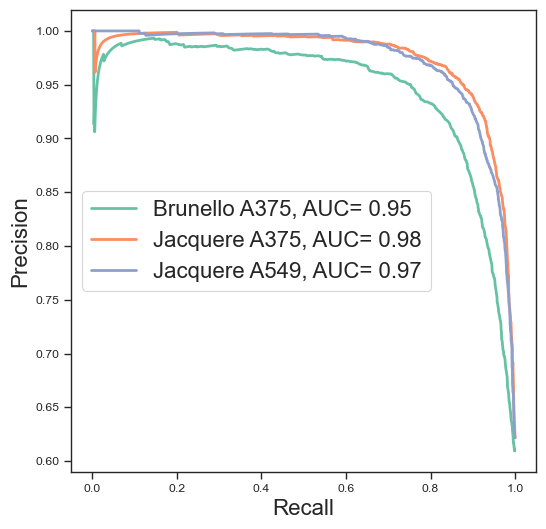

In [22]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(brunello_A375_recall, brunello_A375_precision, label= f'Brunello A375, AUC= {round(auc(brunello_A375_recall, brunello_A375_precision),2)}',linewidth=2)
ax.plot(jacquere_A375_recall, jacquere_A375_precision, label= f'Jacquere A375, AUC= {round(auc(jacquere_A375_recall, jacquere_A375_precision),2)}',linewidth=2)
ax.plot(jacquere_A549_recall, jacquere_A549_precision, label= f'Jacquere A549, AUC= {round(auc(jacquere_A549_recall, jacquere_A549_precision),2)}',linewidth=2)

ax.set_xlabel('Recall',fontsize=16)
ax.set_ylabel('Precision',fontsize=16)
ax.legend(loc='center left',fontsize=16)
gpp.savefig("../Figures/Jacquere_vs_Brunello_PRC.pdf")

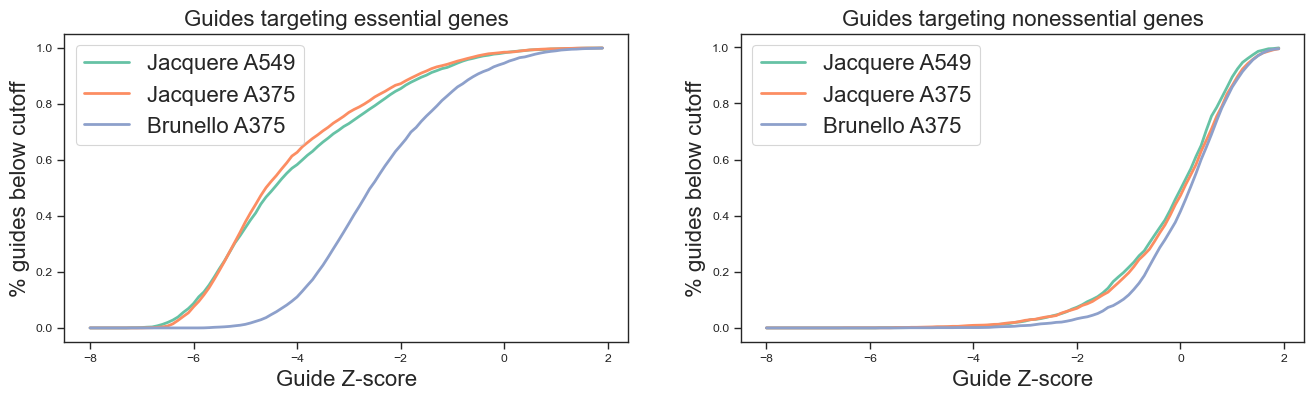

In [23]:
zscored_guide_lfcs_essentials=jacquere_and_brunello[jacquere_and_brunello["Target Gene Symbol"].isin(essential_genes["Gene"].tolist())].reset_index(drop=True)
#remove repeated guide sequences within the same condition
zscored_guide_lfcs_essentials=zscored_guide_lfcs_essentials.drop_duplicates(["Construct Barcode","condition"])
zscored_guide_lfcs_essentials_A375=zscored_guide_lfcs_essentials[zscored_guide_lfcs_essentials["condition"]=="Jacquere A375"].reset_index(drop=True)
zscored_guide_lfcs_essentials_A549=zscored_guide_lfcs_essentials[zscored_guide_lfcs_essentials["condition"]=="Jacquere A549"].reset_index(drop=True)
zscored_guide_lfcs_essentials_brunello=zscored_guide_lfcs_essentials[zscored_guide_lfcs_essentials["condition"]=="Brunello A375"].reset_index(drop=True)

guide_z_cutoffs= [x*0.1 for x in range(-80,20)]

percent_guides_below_cutoff_jacquereA375=[]
percent_guides_below_cutoff_jacquereA549=[]
percent_guides_below_cutoff_brunelloA375=[]

for cutoff in guide_z_cutoffs:
    percent_guides_below_cutoff_jacquereA375.append(len(zscored_guide_lfcs_essentials_A375[zscored_guide_lfcs_essentials_A375["z_scored_sgRNA_lfc"]<cutoff])/len(zscored_guide_lfcs_essentials_A375))
    percent_guides_below_cutoff_jacquereA549.append(len(zscored_guide_lfcs_essentials_A549[zscored_guide_lfcs_essentials_A549["z_scored_sgRNA_lfc"]<cutoff])/len(zscored_guide_lfcs_essentials_A549))
    percent_guides_below_cutoff_brunelloA375.append(len(zscored_guide_lfcs_essentials_brunello[zscored_guide_lfcs_essentials_brunello["z_scored_sgRNA_lfc"]<cutoff])/len(zscored_guide_lfcs_essentials_brunello))

fig, ax = plt.subplots(1,2,figsize=(16,4))
ax[0].plot(guide_z_cutoffs,percent_guides_below_cutoff_jacquereA549,label="Jacquere A549",linewidth=2)
ax[0].plot(guide_z_cutoffs,percent_guides_below_cutoff_jacquereA375,label="Jacquere A375",linewidth=2)
ax[0].plot(guide_z_cutoffs,percent_guides_below_cutoff_brunelloA375,label="Brunello A375",linewidth=2)
ax[0].set_xlabel("Guide Z-score",fontsize=16)
ax[0].set_ylabel("% guides below cutoff",fontsize=16)
ax[0].set_title("Guides targeting essential genes",fontsize=16)
ax[0].legend(fontsize=16)

#repeat for nonessentials
zscored_guide_lfcs_nonessentials=jacquere_and_brunello[jacquere_and_brunello["Target Gene Symbol"].isin(noness_genes["Gene"].tolist())].reset_index(drop=True)
#remove repeated guide sequences within the same condition
zscored_guide_lfcs_nonessentials=zscored_guide_lfcs_nonessentials.drop_duplicates(["Construct Barcode","condition"])
zscored_guide_lfcs_nonessentials_A375=zscored_guide_lfcs_nonessentials[zscored_guide_lfcs_nonessentials["condition"]=="Jacquere A375"].reset_index(drop=True)
zscored_guide_lfcs_nonessentials_A549=zscored_guide_lfcs_nonessentials[zscored_guide_lfcs_nonessentials["condition"]=="Jacquere A549"].reset_index(drop=True)
zscored_guide_lfcs_nonessentials_brunello=zscored_guide_lfcs_nonessentials[zscored_guide_lfcs_nonessentials["condition"]=="Brunello A375"].reset_index(drop=True)

percent_guides_below_cutoff_jacquereA375=[]
percent_guides_below_cutoff_jacquereA549=[]
percent_guides_below_cutoff_brunelloA375=[]
for cutoff in guide_z_cutoffs:
    percent_guides_below_cutoff_jacquereA375.append(len(zscored_guide_lfcs_nonessentials_A375[zscored_guide_lfcs_nonessentials_A375["z_scored_sgRNA_lfc"]<cutoff])/len(zscored_guide_lfcs_nonessentials_A375))
    percent_guides_below_cutoff_jacquereA549.append(len(zscored_guide_lfcs_nonessentials_A549[zscored_guide_lfcs_nonessentials_A549["z_scored_sgRNA_lfc"]<cutoff])/len(zscored_guide_lfcs_nonessentials_A549))
    percent_guides_below_cutoff_brunelloA375.append(len(zscored_guide_lfcs_nonessentials_brunello[zscored_guide_lfcs_nonessentials_brunello["z_scored_sgRNA_lfc"]<cutoff])/len(zscored_guide_lfcs_nonessentials_brunello))

ax[1].plot(guide_z_cutoffs,percent_guides_below_cutoff_jacquereA549,label="Jacquere A549",linewidth=2)
ax[1].plot(guide_z_cutoffs,percent_guides_below_cutoff_jacquereA375,label="Jacquere A375",linewidth=2)
ax[1].plot(guide_z_cutoffs,percent_guides_below_cutoff_brunelloA375,label="Brunello A375",linewidth=2)
ax[1].set_xlabel("Guide Z-score",fontsize=16)
ax[1].set_ylabel("% guides below cutoff",fontsize=16)
ax[1].set_title("Guides targeting nonessential genes",fontsize=16)
ax[1].legend(fontsize=16)

                       
gpp.savefig("../Figures/Jacquere_vs_Brunello_essentials_nonessentials_guidelevel.pdf")

### Obtaining gene-level z-scores

In [24]:
zscored_gene_lfcs = (jacquere_and_brunello.groupby(['Target Gene Symbol', 'condition'])
                     .agg(z_scored_lfc_sum = ('z_scored_sgRNA_lfc', 'sum'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())
zscored_gene_lfcs['gene_zscore'] = (zscored_gene_lfcs['z_scored_lfc_sum']/np.sqrt(zscored_gene_lfcs['n_sgrnas']))
zscored_gene_lfcs = zscored_gene_lfcs.drop('z_scored_lfc_sum', axis=1)
zscored_gene_lfcs

,Target Gene Symbol,condition,n_sgrnas,gene_zscore
0,A1BG,Brunello A375,3,0.706360
1,A1BG,Jacquere A375,3,-0.134845
2,A1BG,Jacquere A549,3,-0.635792
3,A1BG-AS1,Jacquere A375,1,0.386528
4,A1BG-AS1,Jacquere A549,1,-0.025615
...,...,...,...,...
63239,ZZEF1,Jacquere A375,3,1.473822
63240,ZZEF1,Jacquere A549,3,1.165822
63241,ZZZ3,Brunello A375,4,-2.370159
63242,ZZZ3,Jacquere A375,3,-2.715946


Plot to identify the percent of essential genes that have a z-score over (n)

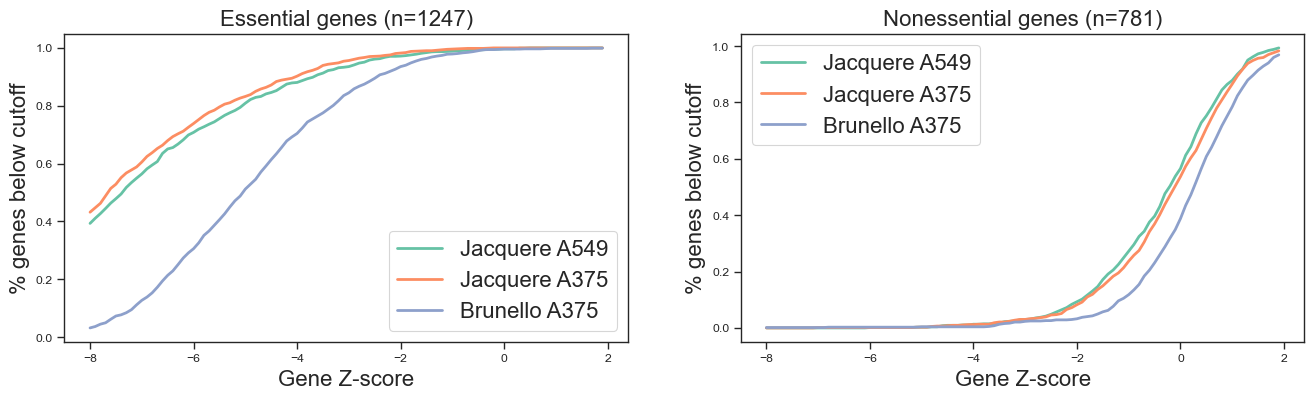

In [25]:
zscored_gene_lfcs_essentials=zscored_gene_lfcs[zscored_gene_lfcs["Target Gene Symbol"].isin(essential_genes["Gene"].tolist())].reset_index(drop=True)
zscored_gene_lfcs_essentials_A375=zscored_gene_lfcs_essentials[zscored_gene_lfcs_essentials["condition"]=="Jacquere A375"].reset_index(drop=True)
zscored_gene_lfcs_essentials_A549=zscored_gene_lfcs_essentials[zscored_gene_lfcs_essentials["condition"]=="Jacquere A549"].reset_index(drop=True)
zscored_gene_lfcs_essentials_brunello=zscored_gene_lfcs_essentials[zscored_gene_lfcs_essentials["condition"]=="Brunello A375"].reset_index(drop=True)

gene_z_cutoffs= [x*0.1 for x in range(-80,20)]

percent_genes_below_cutoff_jacquereA375=[]
percent_genes_below_cutoff_jacquereA549=[]
percent_genes_below_cutoff_brunelloA375=[]

for cutoff in gene_z_cutoffs:
    percent_genes_below_cutoff_jacquereA375.append(len(zscored_gene_lfcs_essentials_A375[zscored_gene_lfcs_essentials_A375["gene_zscore"]<cutoff])/len(zscored_gene_lfcs_essentials_A375))
    percent_genes_below_cutoff_jacquereA549.append(len(zscored_gene_lfcs_essentials_A549[zscored_gene_lfcs_essentials_A549["gene_zscore"]<cutoff])/len(zscored_gene_lfcs_essentials_A549))
    percent_genes_below_cutoff_brunelloA375.append(len(zscored_gene_lfcs_essentials_brunello[zscored_gene_lfcs_essentials_brunello["gene_zscore"]<cutoff])/len(zscored_gene_lfcs_essentials_brunello))

fig, ax = plt.subplots(1,2,figsize=(16,4))
ax[0].plot(gene_z_cutoffs,percent_genes_below_cutoff_jacquereA549,label="Jacquere A549",linewidth=2)
ax[0].plot(gene_z_cutoffs,percent_genes_below_cutoff_jacquereA375,label="Jacquere A375",linewidth=2)
ax[0].plot(gene_z_cutoffs,percent_genes_below_cutoff_brunelloA375,label="Brunello A375",linewidth=2)
ax[0].set_xlabel("Gene Z-score",fontsize=16)
ax[0].set_ylabel("% genes below cutoff",fontsize=16)
ax[0].set_title("Essential genes (n="+str(len(essential_genes["Gene"].tolist()))+")",fontsize=16)
ax[0].legend(fontsize=16)

#repeat for nonessentials
zscored_gene_lfcs_nonessentials=zscored_gene_lfcs[zscored_gene_lfcs["Target Gene Symbol"].isin(noness_genes["Gene"].tolist())].reset_index(drop=True)
zscored_gene_lfcs_nonessentials_A375=zscored_gene_lfcs_nonessentials[zscored_gene_lfcs_nonessentials["condition"]=="Jacquere A375"].reset_index(drop=True)
zscored_gene_lfcs_nonessentials_A549=zscored_gene_lfcs_nonessentials[zscored_gene_lfcs_nonessentials["condition"]=="Jacquere A549"].reset_index(drop=True)
zscored_gene_lfcs_nonessentials_brunello=zscored_gene_lfcs_nonessentials[zscored_gene_lfcs_nonessentials["condition"]=="Brunello A375"].reset_index(drop=True)

percent_genes_below_cutoff_jacquereA375=[]
percent_genes_below_cutoff_jacquereA549=[]
percent_genes_below_cutoff_brunelloA375=[]
for cutoff in gene_z_cutoffs:
    percent_genes_below_cutoff_jacquereA375.append(len(zscored_gene_lfcs_nonessentials_A375[zscored_gene_lfcs_nonessentials_A375["gene_zscore"]<cutoff])/len(zscored_gene_lfcs_nonessentials_A375))
    percent_genes_below_cutoff_jacquereA549.append(len(zscored_gene_lfcs_nonessentials_A549[zscored_gene_lfcs_nonessentials_A549["gene_zscore"]<cutoff])/len(zscored_gene_lfcs_nonessentials_A549))
    percent_genes_below_cutoff_brunelloA375.append(len(zscored_gene_lfcs_nonessentials_brunello[zscored_gene_lfcs_nonessentials_brunello["gene_zscore"]<cutoff])/len(zscored_gene_lfcs_nonessentials_brunello))

ax[1].plot(gene_z_cutoffs,percent_genes_below_cutoff_jacquereA549,label="Jacquere A549",linewidth=2)
ax[1].plot(gene_z_cutoffs,percent_genes_below_cutoff_jacquereA375,label="Jacquere A375",linewidth=2)
ax[1].plot(gene_z_cutoffs,percent_genes_below_cutoff_brunelloA375,label="Brunello A375",linewidth=2)
ax[1].set_xlabel("Gene Z-score",fontsize=16)
ax[1].set_ylabel("% genes below cutoff",fontsize=16)
ax[1].set_title("Nonessential genes (n="+str(len(noness_genes["Gene"].tolist()))+")",fontsize=16)
ax[1].legend(fontsize=16)
                       
gpp.savefig("../Figures/Jacquere_vs_Brunello_essentials_nonessentials_genelevel.pdf")

### Identifying gene hits with empirical p-value

The Z-score method typically lends itself to direct statistical interpretation; assuming normally distributed controls, the z-score reflects the number of standard deviations away from the null mean, so a z of -2 associates with p=0.05 and so on. However, the intergenic controls in Jacquere are not normally distributed. Thus, we must calculate an empirical p value to test if genes in jacquere are significantly different from negative controls. The null distribution is constructed from pseudogenes; groups of intergenic guides with 3 guides per "pseudogene".

While the controls of Brunello are normally distributed, thus direct interpretation of the z-scores for statistical significance would not be inaccurate, the same will be applied to the Brunello library for direct comparison to the analysis of Jacquere. 

In [26]:
jacquere_and_brunello["negative control"]= jacquere_and_brunello.apply(lambda x: 
                                                                       True if (x.condition.count("Jacquere")>0 and x["Target Gene Symbol"]=="ONE_SITE_INTERGENIC") or
                                                                       (x.condition.count("Brunello")>0 and x["Target Gene Symbol"]=="ONE_INTERGENIC_SITE") else False,axis=1)

jacquere_and_brunello[["negative control","condition"]].value_counts()

negative control  condition    
False             Brunello A375    86364
                  Jacquere A375    64899
                  Jacquere A549    64899
True              Jacquere A375      897
                  Jacquere A549      897
                  Brunello A375       23
Name: count, dtype: int64

In [27]:
#randomly sample controls to create pseudogenes, calculate aggregate z-score for each pseudogene
def get_pseudogene_distribution(df_with_guide_zscores,df_with_gene_zscores):
    #get guide-level z-scores of controls
    control_zscores= df_with_guide_zscores[df_with_guide_zscores["negative control"]].reset_index(drop=True)

    #num guides in each pseudogene is average num guides per gene in screen 
    num_guides_per_pseudogene= round(df_with_gene_zscores["n_sgrnas"].mean())
    
    random.seed(0)
    num_pseudogenes=1000
    control_pseudogene_zscores=[]
    for i in range(num_pseudogenes):
        #select n random indices from the list of control guides (n being the number of guides in a pseudogene)
        #sampling with replacement enables a more representative distribution, beneficial for small control set size
        control_guides_in_pseudogene=random.choices(range(len(control_zscores)), k=num_guides_per_pseudogene)
        control_pseudogene= control_zscores.loc[control_guides_in_pseudogene,:]
        #implements stouffers to calculate pseudogene-level z-score from z-score of each guide in pseudogene 
        control_pseudogene_zscores.append( control_pseudogene["z_scored_sgRNA_lfc"].sum()/np.sqrt(num_guides_per_pseudogene))
    control_pseudogene_zscores.sort()
    return control_pseudogene_zscores

#calculate control pseudogene distribution separately for each condition
control_pseudogene_zscore_distribution_map={}
for condition in zscored_gene_lfcs["condition"].unique():
    control_pseudogene_zscore_distribution_map[condition]= get_pseudogene_distribution(jacquere_and_brunello[jacquere_and_brunello["condition"]==condition].reset_index(),zscored_gene_lfcs[zscored_gene_lfcs["condition"]==condition].reset_index())

def get_empirical_gene_pval(gene_level_z_score,condition):
    #use the control distribution that corresponds to the condition that the gene-level z-score is calculated from
    control_pseudogene_zscores= control_pseudogene_zscore_distribution_map[condition]
    #estimate probability distribution of pseudogene z-scores to get AUC for pval
    kde= scipy.stats.gaussian_kde(control_pseudogene_zscores)
    ha_less=kde.integrate_box_1d(-np.inf, gene_level_z_score)
    #ha_greater=kde.integrate_box_1d(gene_level_z_score, np.inf) #return strongest_p_val if interested in positive selection hits too 
    #strongest_p_val=np.min([ha_less,ha_greater])
    return ha_less

zscored_gene_lfcs['empirical_pvalue'] = zscored_gene_lfcs.apply(lambda x: get_empirical_gene_pval(x.gene_zscore,x.condition),axis=1)

#obtaining False Discovery Rate with Benjamini-Hochberg multiple testing correction 
zscored_gene_lfcs=zscored_gene_lfcs.sort_values(by="condition")
zscored_gene_lfcs_agg_by_condition=zscored_gene_lfcs.groupby("condition").agg(list).reset_index()
zscored_gene_lfcs_agg_by_condition["FDR"]=zscored_gene_lfcs_agg_by_condition["empirical_pvalue"].apply(lambda x: multipletests(x,method="fdr_bh")[1])
zscored_gene_lfcs["FDR"]= zscored_gene_lfcs_agg_by_condition["FDR"].explode().tolist()

zscored_gene_lfcs

,Target Gene Symbol,condition,n_sgrnas,gene_zscore,empirical_pvalue,FDR
0,A1BG,Brunello A375,3,0.706360,7.414835e-01,9.798043e-01
33139,MRPL57,Brunello A375,4,-4.153298,6.704713e-08,7.338151e-07
33136,MRPL55,Brunello A375,4,-3.813132,7.239263e-06,7.012109e-05
33133,MRPL54,Brunello A375,4,-4.910732,4.322200e-15,6.418821e-14
33130,MRPL53,Brunello A375,4,-4.893886,6.866578e-15,1.012516e-13
...,...,...,...,...,...,...
37400,OR2AE1,Jacquere A549,3,-1.117120,1.397217e-01,4.188097e-01
8948,CFAP107,Jacquere A549,3,1.511588,9.454115e-01,9.911220e-01
37397,OR2A7,Jacquere A549,3,-2.170242,2.836650e-02,1.423962e-01
37391,OR2A42,Jacquere A549,4,-2.096435,3.242164e-02,1.576645e-01


In [28]:
zscored_gene_lfcs[zscored_gene_lfcs["condition"].isin(["Jacquere A375","Brunello A375"])].to_csv("../Data/jacquere_brunello_A375_zscoremethod.csv",index=False)

Note that in a standard screen analysis we recommend only retaining genes with at least 2 sgrnas to determine hits, but retaining here for the purpose of demonstrating that Jacquere covers hard-to-target genes. 

Hits are recognized here as those with FDR <0.05

In [29]:
hit_genes=zscored_gene_lfcs[zscored_gene_lfcs["FDR"]<0.05]
hit_genes["condition"].value_counts()

condition
Jacquere A375    3588
Brunello A375    3348
Jacquere A549    3282
Name: count, dtype: int64

Identify the # of nonessential genes that emerge as a depleting hit

In [30]:
falsepositives=hit_genes[(hit_genes["condition"]=="Jacquere A375")&(hit_genes["Target Gene Symbol"].isin(noness_genes["Gene"].tolist()))&(hit_genes["gene_zscore"]<0)]
print(len(falsepositives))

26


In [31]:
len(zscored_gene_lfcs[zscored_gene_lfcs["Target Gene Symbol"].isin(noness_genes["Gene"].tolist())&(zscored_gene_lfcs["condition"]=="Jacquere A375")])

764

### Essential gene hits recovered by Jacquere
Identifying essential gene hits recovered by Jacquere (A375 only) due to the fact that they are not targeted in Brunello

In [32]:
jacquere_with_fdr=zscored_gene_lfcs[zscored_gene_lfcs["condition"]=="Jacquere A375"]
brunello_with_fdr=zscored_gene_lfcs[zscored_gene_lfcs["condition"]=="Brunello A375"]

essentials_jacquere_with_fdr=jacquere_with_fdr[jacquere_with_fdr["Target Gene Symbol"].isin(essential_genes["Gene"].tolist())]
essentials_brunello_with_fdr=brunello_with_fdr[brunello_with_fdr["Target Gene Symbol"].isin(essential_genes["Gene"].tolist())]

print("% of essential genes in Brunello that deplete FDR < 0.05 (A375):",round(len(essentials_brunello_with_fdr[essentials_brunello_with_fdr["FDR"]<0.05])/len(essentials_brunello_with_fdr),3)*100)
print("% of essential genes in Jacquere that deplete FDR < 0.05 (A375):",round(len(essentials_jacquere_with_fdr[essentials_jacquere_with_fdr["FDR"]<0.05])/len(essentials_jacquere_with_fdr),3)*100)


essentials_not_targeted_by_brunello=[gene for gene in essential_genes["Gene"].tolist() if gene not in essentials_brunello_with_fdr["Target Gene Symbol"].tolist() and gene in essentials_jacquere_with_fdr["Target Gene Symbol"].tolist()]
print("\n# essential genes not targeted in brunello that are targeted in jacquere:", len(essentials_not_targeted_by_brunello))
print("median FDR from jacquere A375 screen of essential genes not targeted by brunello:", essentials_jacquere_with_fdr[essentials_jacquere_with_fdr["Target Gene Symbol"].isin(essentials_not_targeted_by_brunello)]["FDR"].median())
print("least severe FDR from jacquere A375 screen of essential genes not targeted by brunello:", essentials_jacquere_with_fdr[essentials_jacquere_with_fdr["Target Gene Symbol"].isin(essentials_not_targeted_by_brunello)]["FDR"].max())

% of essential genes in Brunello that deplete FDR < 0.05 (A375): 89.4
% of essential genes in Jacquere that deplete FDR < 0.05 (A375): 96.39999999999999

# essential genes not targeted in brunello that are targeted in jacquere: 4
median FDR from jacquere A375 screen of essential genes not targeted by brunello: 1.0907348309247885e-32
least severe FDR from jacquere A375 screen of essential genes not targeted by brunello: 1.5284422288394825e-16


All essential genes targeted in Jacquere and not Brunello emerge as depleted hits. 

Identifying essential gene hits recovered by Jacquere (A375) for having z < -2

In [33]:
nonscoring_essentials_brunello=essentials_brunello_with_fdr[essentials_brunello_with_fdr["FDR"]>0.05]["Target Gene Symbol"].tolist()
nonscoring_essentials_jacquere= essentials_jacquere_with_fdr[essentials_jacquere_with_fdr["FDR"]>0.05]["Target Gene Symbol"].tolist()

print("# essential genes that are not a hit in brunello:",len(nonscoring_essentials_brunello))
nonscoring_essentials_both_libraries=[gene for gene in nonscoring_essentials_brunello if gene in nonscoring_essentials_jacquere]
print("# essential genes that are not a hit in both libraries:",len(nonscoring_essentials_both_libraries))
nonscoring_essentials_jacquere_only=[gene for gene in nonscoring_essentials_jacquere if gene not in nonscoring_essentials_brunello]
print("# essential genes that are not a hit in jacquere only:",len(nonscoring_essentials_jacquere_only))
nonscoring_essentials_brunello_only=[gene for gene in nonscoring_essentials_brunello if gene not in nonscoring_essentials_jacquere]
print("# essential genes that are not a hit in brunello only:",len(nonscoring_essentials_brunello_only))


# essential genes that are not a hit in brunello: 131
# essential genes that are not a hit in both libraries: 34
# essential genes that are not a hit in jacquere only: 11
# essential genes that are not a hit in brunello only: 97


Identifying if the essential genes that emerge as a hit in Jacquere but not Brunello are an artifact of stronger on-target activity (as measured by RS3) of guides selected for Jacquere

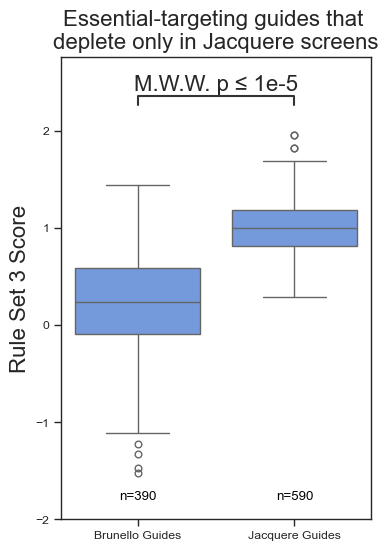

In [34]:
jacquere_guideinfo_nonscoring_essentials_brunello_only=zscored_sgrna_lfcs[zscored_sgrna_lfcs["Target Gene Symbol"].isin(nonscoring_essentials_brunello_only)]
brunello_guideinfo_nonscoring_essentials_brunello_only=brunello_zscores[brunello_zscores["Target Gene Symbol"].isin(nonscoring_essentials_brunello_only)]

nonscoring_essentials_brunello_only_bothlibraryguides=pd.concat([brunello_guideinfo_nonscoring_essentials_brunello_only,jacquere_guideinfo_nonscoring_essentials_brunello_only],keys=("Brunello Guides","Jacquere Guides")).reset_index() 
nonscoring_essentials_brunello_only_bothlibraryguides["On-Target Efficacy Score"]=nonscoring_essentials_brunello_only_bothlibraryguides["On-Target Efficacy Score"].astype(float)

plt.figure(figsize=(4,6))

ax = sns.boxplot(x=nonscoring_essentials_brunello_only_bothlibraryguides['level_0'], y=nonscoring_essentials_brunello_only_bothlibraryguides["On-Target Efficacy Score"],color = 'cornflowerblue')

nobs = [str(x) for x in [len(nonscoring_essentials_brunello_only_bothlibraryguides[nonscoring_essentials_brunello_only_bothlibraryguides["level_0"]=="Brunello Guides"]),len(nonscoring_essentials_brunello_only_bothlibraryguides[nonscoring_essentials_brunello_only_bothlibraryguides["level_0"]=="Jacquere Guides"])]]
nobs = ["n=" + i for i in nobs]
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],-1.8,
            nobs[tick],
            horizontalalignment='center',
            size='medium',
            color='black')

plt.ylabel("Rule Set 3 Score",fontsize=16)
plt.xlabel("")
plt.ylim(-2,2.6)
plt.title("Essential-targeting guides that \ndeplete only in Jacquere screens",fontsize=16)

annotator = Annotator(ax, [("Brunello Guides","Jacquere Guides")], data=nonscoring_essentials_brunello_only_bothlibraryguides, x="level_0", y='On-Target Efficacy Score', order=["Brunello Guides","Jacquere Guides"],verbose=False)
annotator.configure(test='Mann-Whitney', text_format='simple',fontsize=16) #this shows test name, actual p value
annotator.apply_and_annotate()

gpp.savefig("../Figures/RS3scores_essentials_depleted_jacquere_not_brunello.pdf",bbox_inches="tight")


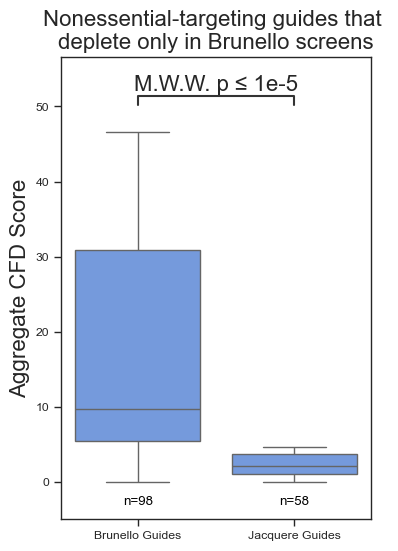

In [41]:
scoring_nonessentials_jacquere= jacquere_with_fdr[(jacquere_with_fdr["Target Gene Symbol"].isin(noness_genes["Gene"].tolist()))&(jacquere_with_fdr["FDR"]<0.05)]["Target Gene Symbol"].tolist()
scoring_nonessentials_brunello= brunello_with_fdr[(brunello_with_fdr["Target Gene Symbol"].isin(noness_genes["Gene"].tolist()))&(brunello_with_fdr["FDR"]<0.05)]["Target Gene Symbol"].tolist()
depleted_nonessentials_brunello_only=[gene for gene in scoring_nonessentials_brunello if gene not in scoring_nonessentials_jacquere]

depleted_nonessentials_brunello_only_brunello_guideinfo=brunello_zscores[brunello_zscores["Target Gene Symbol"].isin(depleted_nonessentials_brunello_only)]
depleted_nonessentials_brunello_only_jacquere_guideinfo=zscored_sgrna_lfcs[zscored_sgrna_lfcs["Target Gene Symbol"].isin(depleted_nonessentials_brunello_only)]
depleted_nonessentials_brunello_only_bothlibraryguides=pd.concat([depleted_nonessentials_brunello_only_brunello_guideinfo,depleted_nonessentials_brunello_only_jacquere_guideinfo],keys=("Brunello Guides","Jacquere Guides")).reset_index() 
depleted_nonessentials_brunello_only_bothlibraryguides=depleted_nonessentials_brunello_only_bothlibraryguides[depleted_nonessentials_brunello_only_bothlibraryguides["Aggregate CFD Score"]!="MAX"]
depleted_nonessentials_brunello_only_bothlibraryguides["Aggregate CFD Score"]=depleted_nonessentials_brunello_only_bothlibraryguides["Aggregate CFD Score"].astype(float)

plt.figure(figsize=(4,6))

ax=sns.boxplot(x=depleted_nonessentials_brunello_only_bothlibraryguides['level_0'], y=depleted_nonessentials_brunello_only_bothlibraryguides["Aggregate CFD Score"],color = 'cornflowerblue')

nobs = [str(x) for x in [len(depleted_nonessentials_brunello_only_bothlibraryguides[depleted_nonessentials_brunello_only_bothlibraryguides["level_0"]=="Brunello Guides"]),len(depleted_nonessentials_brunello_only_bothlibraryguides[depleted_nonessentials_brunello_only_bothlibraryguides["level_0"]=="Jacquere Guides"])]]
nobs = ["n=" + i for i in nobs]
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],-3,
            nobs[tick],
            horizontalalignment='center',
            size='medium',
            color='black')


plt.ylabel("Aggregate CFD Score",fontsize=16)
plt.xlabel("")
plt.ylim(-5,55)
plt.title("Nonessential-targeting guides that \ndeplete only in Brunello screens",fontsize=16)

annotator = Annotator(ax, [("Brunello Guides","Jacquere Guides")], data=depleted_nonessentials_brunello_only_bothlibraryguides, x="level_0", y='Aggregate CFD Score', order=["Brunello Guides","Jacquere Guides"],verbose=False)
annotator.configure(test='Mann-Whitney', text_format='simple',fontsize=16) #this shows test name, actual p value
annotator.apply_and_annotate()

gpp.savefig("../Figures/RS3scores_nonessentials_depleted_brunello_not_jacquere.pdf",bbox_inches="tight")


Significance testing with chi square test of independence : significant result rejects the null hypothesis that RS3 >= 0.2 is not associated with improved on-target activity (essential-targeting FDR<0.05)
*only applied for brunello since jacquere is underrepresented for guides with RS3<0.2*

In [36]:
brunello_essentials_with_crispick=brunello_zscores.merge(essentials_brunello_with_fdr)
print(len(brunello_essentials_with_crispick))
brunello_essentials_with_crispick["RS3 >=0.2"]=brunello_essentials_with_crispick["On-Target Efficacy Score"]>=0.2
brunello_essentials_with_crispick["Depleted"]=brunello_essentials_with_crispick["FDR"]<0.05
brunello_RS3_essentials_depletion_crosstab=pd.crosstab(brunello_essentials_with_crispick["RS3 >=0.2"], brunello_essentials_with_crispick["Depleted"])
print(stats.chi2_contingency(brunello_RS3_essentials_depletion_crosstab))


5061
Chi2ContingencyResult(statistic=np.float64(33.15097067238933), pvalue=np.float64(8.52737953561736e-09), dof=1, expected_freq=array([[ 194.1025489, 1662.8974511],
       [ 334.8974511, 2869.1025489]]))
